Early stopping at epoch 97
Train R²: 0.9935
Test  R²: 0.9970
R² Gap (Train - Test): -0.0035
Train RMSE: 18.0401
Test  RMSE: 12.7501
RMSE Gap (Test - Train): -5.2900


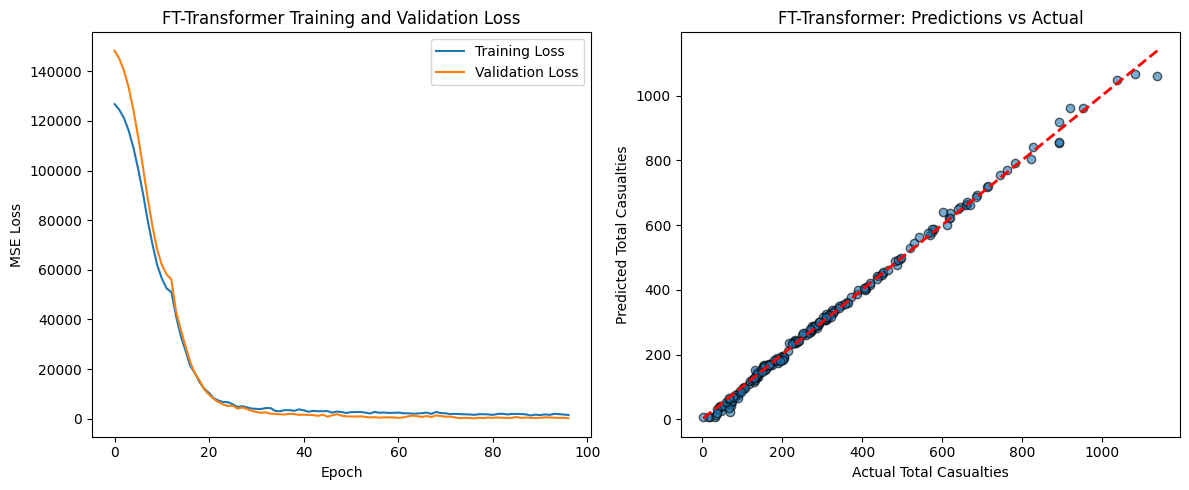

In [1]:
import subprocess
import sys
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch"])
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Augmented Dataset of Nigeria Crash.csv')
categorical_cols = ['Quarter', 'State', 'Region']
numerical_cols = [c for c in df.columns if c not in categorical_cols + ['Quarter_Date', 'State_Encoded']]
numerical_cols = [c for c in numerical_cols if df[c].dtype in ['float64', 'int64']]
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())
for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')
    le = LabelEncoder()
    df[col+'_code'] = le.fit_transform(df[col].astype(str))
cat_encoded_cols = [col+'_code' for col in categorical_cols]
all_features = numerical_cols + cat_encoded_cols
target = 'Total_Casualties'
X = df[all_features].copy()
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
num_scaler = StandardScaler()
X_train_num = X_train[numerical_cols].values
X_test_num = X_test[numerical_cols].values
X_train_num_scaled = num_scaler.fit_transform(X_train_num)
X_test_num_scaled = num_scaler.transform(X_test_num)
X_train_cat = X_train[cat_encoded_cols].values
X_test_cat = X_test[cat_encoded_cols].values
cat_dim = len(cat_encoded_cols)
num_dim = len(numerical_cols)
total_dim = num_dim + cat_dim
X_train_combined = np.hstack([X_train_num_scaled, X_train_cat])
X_test_combined = np.hstack([X_test_num_scaled, X_test_cat])
X_train_tensor = torch.tensor(X_train_combined, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_combined, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

class FTTransformer(nn.Module):
    def __init__(self, num_numerical, num_categorical, d_model=128, nhead=8, num_layers=4, dim_feedforward=256, dropout=0.2):
        super().__init__()
        self.numerical_proj = nn.Linear(num_numerical, d_model)
        self.categorical_embeddings = nn.ModuleList([nn.Embedding(int(X_train_cat[:,i].max())+1, d_model) for i in range(num_categorical)])
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        self.pos_encoding = nn.Parameter(torch.randn(1, num_numerical + num_categorical + 1, d_model))
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model//2, 1)
        )
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        num_x = x[:, :self.numerical_proj.in_features]
        cat_x = x[:, self.numerical_proj.in_features:].long()
        num_emb = self.numerical_proj(num_x).unsqueeze(1)
        cat_embs = [emb(cat_x[:, i]).unsqueeze(1) for i, emb in enumerate(self.categorical_embeddings)]
        cat_emb = torch.cat(cat_embs, dim=1)
        all_emb = torch.cat([num_emb, cat_emb], dim=1)
        batch_size = all_emb.size(0)
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        all_emb = torch.cat([cls_tokens, all_emb], dim=1)
        all_emb = all_emb + self.pos_encoding[:, :all_emb.size(1), :]
        all_emb = self.dropout(all_emb)
        trans_out = self.transformer(all_emb)
        cls_out = trans_out[:, 0, :]
        cls_out = self.norm(cls_out)
        return self.head(cls_out)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FTTransformer(num_numerical=num_dim, num_categorical=cat_dim, d_model=128, nhead=8, num_layers=4, dim_feedforward=256, dropout=0.2).to(device)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
num_epochs = 150
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * batch_x.size(0)
    train_loss /= len(train_loader.dataset)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_x.size(0)
    val_loss /= len(test_loader.dataset)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_ft_transformer.pth')
    else:
        patience_counter += 1
        if patience_counter >= 20:
            print(f'Early stopping at epoch {epoch+1}')
            break
model.load_state_dict(torch.load('best_ft_transformer.pth'))
model.eval()
with torch.no_grad():
    train_pred = model(X_train_tensor.to(device)).cpu().numpy().flatten()
    test_pred = model(X_test_tensor.to(device)).cpu().numpy().flatten()
train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
gap_r2 = train_r2 - test_r2
gap_rmse = test_rmse - train_rmse
print(f"Train R²: {train_r2:.4f}")
print(f"Test  R²: {test_r2:.4f}")
print(f"R² Gap (Train - Test): {gap_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test  RMSE: {test_rmse:.4f}")
print(f"RMSE Gap (Test - Train): {gap_rmse:.4f}")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('FT-Transformer Training and Validation Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.scatter(y_test, test_pred, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Total Casualties')
plt.ylabel('Predicted Total Casualties')
plt.title('FT-Transformer: Predictions vs Actual')
plt.tight_layout()
plt.savefig('ft_transformer_results.png', dpi=150)
plt.show()
try:
    model.eval()
    attention_weights = []
    def hook_fn(module, input, output):
        attention_weights.append(output[1].detach().cpu())
    for layer in model.transformer.layers:
        layer.self_attn.register_forward_hook(hook_fn)
    with torch.no_grad():
        _ = model(X_train_tensor[:1].to(device))
    if attention_weights:
        avg_attn = attention_weights[0].mean(dim=1).squeeze().numpy()
        plt.figure(figsize=(10, 6))
        sns.heatmap(avg_attn, cmap='viridis', cbar=True)
        plt.title('Average Attention Weights (First Transformer Layer)')
        plt.tight_layout()
        plt.savefig('ft_transformer_attention.png', dpi=150)
        plt.show()
except:
    pass